# EfficientNet-B4 Fine-Tuning: RDD2022 Road Defect Classifier

This notebook trains an EfficientNet-B4 model to classify road images into five categories:

| Class | Label |
|-------|-------|
| 0 | Background (no defect) |
| 1 | D00 - Pothole |
| 2 | D10 - Longitudinal crack |
| 3 | D20 - Transverse crack |
| 4 | D40 - Alligator crack |

**Why EfficientNet-B4?**
EfficientNet scales a CNN's depth, width, and input resolution together using a fixed
compound coefficient. B4's 380x380 native input resolution captures fine-grained crack
patterns that smaller variants miss, without requiring the compute of B5 or larger.

**Why fine-tune instead of train from scratch?**
ImageNet pre-training gives the model edge detectors and texture features for free.
Fine-tuning on RDD2022 reuses those features and adapts only the final layers to the
defect domain. This converges faster and needs far fewer labeled examples.

---
Make sure you have downloaded the dataset first:
```bash
python data/download_rdd2022.py
```

## 0. Imports and setup

In [1]:
import sys
sys.path.insert(0, '..')  # let the notebook find the project root

import importlib
import matplotlib.pyplot as plt
import torch
import timm
from pathlib import Path
from torch import nn, optim
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import transforms
from tqdm.notebook import tqdm

import config
importlib.reload(config)
from config import *
from src.datasets.rdd2022 import RDD2022Dataset

set_seeds(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(
    f'Configuration: batch_size={EFFICIENTNET_BATCH_SIZE}, '
    f'workers={EFFICIENTNET_NUM_WORKERS}, epochs={EFFICIENTNET_EPOCHS}'
)

Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Configuration: batch_size=16, workers=2, epochs=50


## 1. Load the dataset

We combine all four country splits (Japan, India, Czech, Norway) into one pool,
then hold out 15% as a validation set. Training images get random flips and
color jitter; validation images get only the resize and normalize.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((EFFICIENTNET_IMG_SIZE, EFFICIENTNET_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((EFFICIENTNET_IMG_SIZE, EFFICIENTNET_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

countries = ['Japan', 'India', 'Czech', 'Norway']
train_datasets = []
val_datasets = []
for country in countries:
    country_dir = str(RDD2022_DIR / country)
    if Path(country_dir).exists():
        train_datasets.append(
            RDD2022Dataset(country_dir, split='train', transform=train_transform)
        )
        val_datasets.append(
            RDD2022Dataset(country_dir, split='train', transform=val_transform)
        )
    else:
        print(f'Warning: {country_dir} not found, skipping.')

train_full_dataset = ConcatDataset(train_datasets)
val_full_dataset = ConcatDataset(val_datasets)

val_size = int(0.15 * len(train_full_dataset))
train_size = len(train_full_dataset) - val_size
split_indices = torch.randperm(
    len(train_full_dataset),
    generator=torch.Generator().manual_seed(SEED),
 ).tolist()
train_indices = split_indices[:train_size]
val_indices = split_indices[train_size:]
train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(val_full_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=True,
    num_workers=EFFICIENTNET_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=EFFICIENTNET_NUM_WORKERS > 0,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=False,
    num_workers=EFFICIENTNET_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=EFFICIENTNET_NUM_WORKERS > 0,
 )

print(f'Training samples:   {train_size:,}')
print(f'Validation samples: {val_size:,}')

Training samples:   24,822
Validation samples: 4,380


## 2. Build the model

We load EfficientNet-B4 pre-trained on ImageNet and replace its classifier
head with a new linear layer sized to our 5-class problem.
AdamW is used with a step decay scheduler that drops the learning rate
by 10x halfway through training.

In [3]:
model = timm.create_model(
    EFFICIENTNET_MODEL,
    pretrained=True,
    num_classes=RDD2022_NUM_CLASSES,
    drop_rate=0.2,
 )
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=EFFICIENTNET_LR,
    weight_decay=EFFICIENTNET_WEIGHT_DECAY,
 )
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=max(1, EFFICIENTNET_EPOCHS // 2),
    gamma=0.1,
 )
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=DEVICE.type == 'cuda',
 )

Trainable parameters: 17,557,581


## 3. Training loop

Each epoch runs one pass over the training set and one pass over the
validation set. The best checkpoint (by validation accuracy) is saved
to disk so we can reload it for evaluation.

In [4]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
    device: torch.device,
 ) -> tuple[float, float]:
    """One pass over the training set. Returns (avg loss, accuracy)."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=device.type == 'cuda',
        ):
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
 ) -> tuple[float, float]:
    """Evaluate on a data loader. Returns (avg loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val  ', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=device.type == 'cuda',
            ):
                logits = model(images)
                loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

In [5]:
CHECKPOINT_DIR.mkdir(exist_ok=True)

history: dict[str, list[float]] = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
}
best_val_acc = 0.0
patience = 8
min_delta = 1e-3
epochs_without_improvement = 0

for epoch in range(1, EFFICIENTNET_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f'Epoch {epoch}/{EFFICIENTNET_EPOCHS}  '
        f'train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  '
        f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}'
    )

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), RDD2022_CHECKPOINT)
        print(f'  Saved best checkpoint (val_acc={best_val_acc:.3f})')
    else:
        epochs_without_improvement += 1
        print(
            f'  No improvement for {epochs_without_improvement}/{patience} epoch(s)'
        )

    if epochs_without_improvement >= patience:
        print(f'Early stopping after epoch {epoch}.')
        break

print(
    f'\nTraining complete. Best val accuracy: {best_val_acc:.3f} '
    f'after {len(history["val_acc"])} epoch(s)'
 )

Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 1/50  train_loss=1.0491  train_acc=0.599  val_loss=0.8370  val_acc=0.687
  Saved best checkpoint (val_acc=0.687)


Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 15/50  train_loss=0.0843  train_acc=0.972  val_loss=1.2170  val_acc=0.742
  No improvement for 7/8 epoch(s)


Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 16/50  train_loss=0.0712  train_acc=0.976  val_loss=1.2614  val_acc=0.745
  No improvement for 8/8 epoch(s)
Early stopping after epoch 16.

Training complete. Best val accuracy: 0.755 after 16 epoch(s)


## 4. Training curves

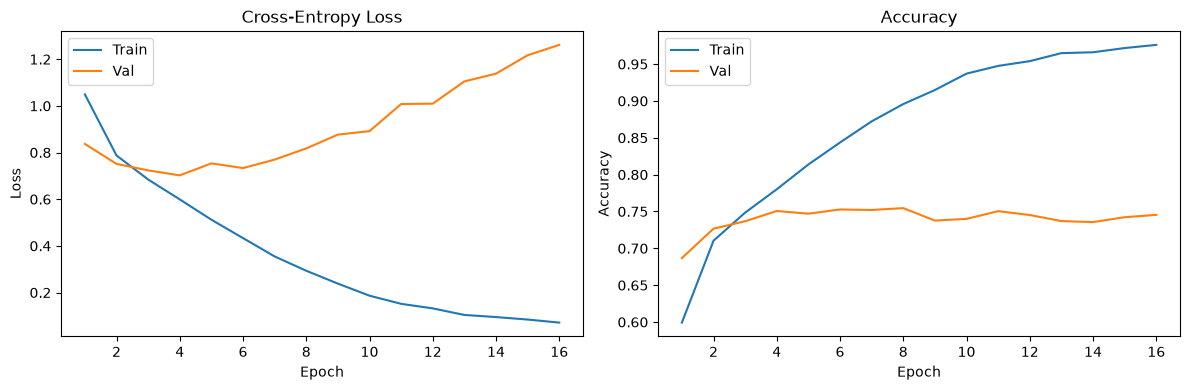

Saved training_curves_rdd2022.png for 16 epoch(s)


In [7]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(epochs, history['train_loss'], label='Train')
axs[0].plot(epochs, history['val_loss'],   label='Val')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Cross-Entropy Loss')
axs[0].legend()

axs[1].plot(epochs, history['train_acc'], label='Train')
axs[1].plot(epochs, history['val_acc'],   label='Val')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.savefig('training_curves_rdd2022.png', dpi=120)
plt.show()
print(f'Saved training_curves_rdd2022.png for {len(history["train_loss"])} epoch(s)')

## 5. Per-class metrics on the validation set

Overall accuracy can mask a model that learned to predict the majority class.
Per-class precision, recall, and F1 give a clearer picture of where the
model is strong and where it struggles.

In [8]:
from sklearn.metrics import classification_report

# Reload the best checkpoint before evaluating.
model.load_state_dict(torch.load(RDD2022_CHECKPOINT, map_location=DEVICE))
model.eval()

all_preds: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Evaluating'):
        logits = model(images.to(DEVICE))
        preds = logits.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

class_names = ['Background', 'Pothole', 'Longitudinal crack', 'Transverse crack', 'Alligator crack']
print(classification_report(all_labels, all_preds, target_names=class_names))

Evaluating:   0%|          | 0/274 [00:00<?, ?it/s]

                    precision    recall  f1-score   support

        Background       0.82      0.91      0.86      2092
           Pothole       0.70      0.57      0.63       963
Longitudinal crack       0.59      0.40      0.48       330
  Transverse crack       0.71      0.74      0.72       686
   Alligator crack       0.62      0.67      0.65       309

          accuracy                           0.75      4380
         macro avg       0.69      0.66      0.67      4380
      weighted avg       0.75      0.75      0.75      4380

